In [ ]:
import gseapy as gp
from lincs_gsnn.explain.infer_edge_weights import infer_edge_weights
import torch 
import pandas as pd 
from lincs_gsnn.explain.viz import annotate_edges, get_drug_edges, make_subgraph
from pypath.utils import mapping

from matplotlib import pyplot as plt 
import numpy as np 

from lincs_gsnn.models.ODEFunc import ODEFunc

from torchdiffeq import odeint

from scipy.stats import hypergeom
from lincs_gsnn.data.TrajDataset import TrajDataset
from torch.utils.data import DataLoader

from gsnn.interpret.IGExplainer import IGExplainer

%load_ext autoreload
%autoreload 2

In [ ]:
root1 = '../../workflow_outputs/lincs-gsnn'
root2 = '../../workflow_outputs/lincs-traj'

data = torch.load(f'{root1}/default/bionetwork/bionetwork.pt', weights_only=False)
gsnn = torch.load(f'{root1}/default/pretrain/pretrained_model.pt', weights_only=False)
dxdt_scale = torch.load(f'{root1}/default/pretrain/dxdt_scale.pt', weights_only=False).item()
x_names = pd.read_csv(f'{root2}/runs/exp/default_v02/output/predict_grid/gene_names.csv')['gene_names'].values.astype(str)
dxdt_meta = pd.read_csv(f'{root2}/runs/exp/default_v02/output/predict_grid/dxdt_meta.csv')
x_meta = pd.read_csv(f'{root2}/runs/exp/default_v02/output/predict_grid/pred_meta.csv')

In [ ]:
x_meta.head()

,pert_id,cell_iname,dose,time_min,time_max,n_time_pts,file_name
0,BRD-K49328571,HME1,0.000,0,72.0,100,pred__BRD-K49328571_HME1_0.0.pt
1,BRD-K49328571,HME1,0.001,0,72.0,100,pred__BRD-K49328571_HME1_0.001.pt
2,BRD-K49328571,HME1,0.010,0,72.0,100,pred__BRD-K49328571_HME1_0.01.pt
3,BRD-K49328571,HME1,0.100,0,72.0,100,pred__BRD-K49328571_HME1_0.1.pt
4,BRD-K49328571,HME1,1.000,0,72.0,100,pred__BRD-K49328571_HME1_1.0.pt


In [ ]:
obs_root = '/home/teddy/local/workflow_outputs/lincs-traj/runs/exp/default_v02/output/predict_grid/obs'

In [ ]:

dataset = TrajDataset(x_meta, 
                      input_names=data.node_names_dict['input'], 
                      obs_dir=obs_root,
                      horizon=None, 
                      multiple_shooting=False)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
model = ODEFunc(gsnn, data.node_names_dict['input'], scale=dxdt_scale).cuda()
model = model.eval()

In [ ]:
xt_mu, xt_sigma, X = dataset.__getitem__(2)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
t = torch.linspace(0, 72, 100).cuda()

out = model.integrate(X.unsqueeze(0).cuda(), t)

out.shape

KeyboardInterrupt: 

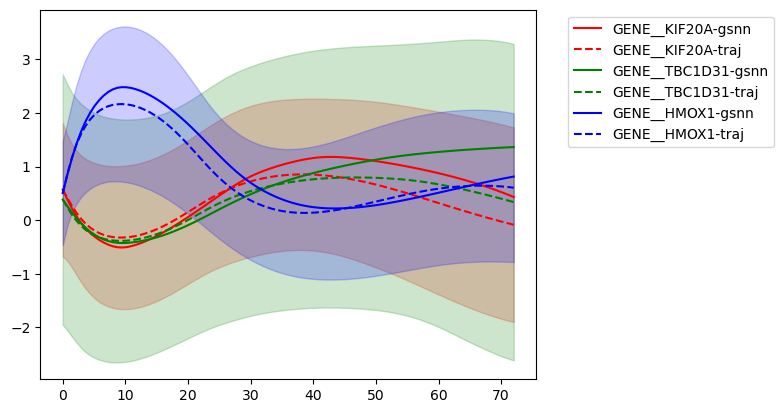

In [ ]:
genes_ixs_to_plot = out.var(0).argsort(-1).view(-1).tolist()[-3:]
gene_names = np.array(model.input_names)[model.gene_ixs]

plt.figure() 
for i,c in zip(genes_ixs_to_plot, ['r', 'g', 'b', 'c', 'm']): 
    plt.plot(t.detach().cpu().numpy(), out[:, 0, i].detach().cpu().numpy(), label=f'{gene_names[i]}-gsnn', color=c)
    
    gene_name = gene_names[i] 
    gene_ix = data.node_names_dict['output'].index(gene_name)
    plt.plot(t.detach().cpu().numpy(), xt_mu[:, gene_ix].detach().cpu().numpy(), label=f'{gene_name}-traj', color=c, linestyle='--')
    plt.fill_between(t.detach().cpu().numpy(), xt_mu[:, gene_ix].detach().cpu().numpy() - 2*xt_sigma[:, gene_ix].detach().cpu().numpy(), xt_mu[:, gene_ix].detach().cpu().numpy() + 2*xt_sigma[:, gene_ix].detach().cpu().numpy(), color=c, alpha=0.2)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show() 

In [ ]:
torch.cuda.empty_cache()

In [ ]:
explainer = IGExplainer(model, data, n_steps=10)

res = explainer.explain(X, target_idx=-1, target='node')


AttributeError: 'ODEFunc' object has no attribute 'edge_index'

In [ ]:
reactome_gene_sets = gp.get_library(name='Reactome_Pathways_2024', organism='Human')

In [ ]:
p1 = list(reactome_gene_sets['PI3K Cascade'])
p2 = list(reactome_gene_sets['MAPK Family Signaling Cascades'])
p3 = list(reactome_gene_sets['Signalling to ERKs'])
p4 = list(reactome_gene_sets['Apoptosis'])
p5 = list(reactome_gene_sets['Constitutive Signaling by Overexpressed ERBB2'])

print(len(p1), len(p2), len(p3), len(p4), len(p5))

44 314 34 168 11


In [ ]:

def convert_to_uniprot(genes):
    unis = set() 
    for g in genes: 
        try: 
            print(g, end='\r')
            uni = mapping.map_name(g, 'genesymbol', 'uniprot')
            if len(uni) > 0: 
                unis = unis.union(uni) 
        except: 
            print(f'{g} not found')
    return list(unis) 

p1 = convert_to_uniprot(p1)
p2 = convert_to_uniprot(p2)
p3 = convert_to_uniprot(p3)
p4 = convert_to_uniprot(p4) 
p5 = convert_to_uniprot(p5)

print(len(p1), len(p2), len(p3), len(p4), len(p5))


PHB not found
MAPK6 GENE not found
MIR34C not found
MIR34B not found
CSF2 GENE not found
MC159L not found
ORF71 not found
SEPT4 not found
44 310 34 168 11


In [ ]:
lines = dxdt_meta.cell_iname.unique()
lines

array(['HME1', 'BT20', 'BT474', 'HS578T', 'MCF10A', 'MCF7', 'MDAMB231',
       'MDAMB468', 'SKBR3', 'T47D', 'ZR751'], dtype=object)

In [ ]:
cell1 = 'BT20' # 'HS578T' # CONTROL lines: MDAMB231
cell2 = 'MDAMB231'
drug = 'BRD-K54997624' # alpelisib (PI3K inhibitor)
dose = 10.

cond_cell1 = dxdt_meta[lambda x: (x.cell_iname == cell1) & (x.pert_id == drug) & (x.dose == dose)]
cond_cell2 = dxdt_meta[lambda x: (x.cell_iname == cell2) & (x.pert_id == drug) & (x.dose == dose)]

print('number obs cell1:', len(cond_cell1))
print('number obs cell2:', len(cond_cell2))

target_genes = x_names #['TP53']

obs_dir = f'{root2}/runs/exp/default_v02/output/predict_grid/dxdt/'


number obs cell1: 100
number obs cell2: 100


In [ ]:

wt_cell1, SWE_cell1, metrics_cell1 = infer_edge_weights(model, data, cond_cell1, target_genes, obs_dir, dxdt_scale, 
                                        n_ctrl_pts=5, degree=3, prior=5, lr=1e-1, beta=1e-3, 
                                        epochs=400, batch_size=600, num_workers=2, dropout=0.)

wt_cell2, SWE_cell2, metrics_cell2 = infer_edge_weights(model, data, cond_cell2, target_genes, obs_dir, dxdt_scale, 
                                        n_ctrl_pts=5, degree=3, prior=5, lr=1e-1, beta=1e-3, 
                                        epochs=400, batch_size=600, num_workers=2, dropout=0.)


In [ ]:
'''
p1 = list(reactome_gene_sets['PI3K Cascade'])
p2 = list(reactome_gene_sets['MAPK Family Signaling Cascades'])
p3 = list(reactome_gene_sets['Signalling to ERKs'])
p4 = list(reactome_gene_sets['Apoptosis'])
p5 = list(reactome_gene_sets['Constitutive Signaling by Overexpressed ERBB2'])
'''


def test_hgeom(genelist, pathway, data): 
    # Get the universe of genes that can be selected (only function nodes with UniProt IDs)
    universe_genes = set()
    for node_name in data.node_names_dict['function']:
        if '__' in node_name:
            universe_genes.add(node_name.split('__')[1])
    
    # Filter pathway and genelist to only include genes in the network universe
    pathway_filtered = list(set(pathway).intersection(universe_genes))
    genelist_filtered = list(set(genelist).intersection(universe_genes))
    
    N = len(universe_genes)  # Total genes that could be selected
    K = len(pathway_filtered)  # Pathway genes in the universe
    n = len(genelist_filtered)  # Genelist genes in the universe  
    k = len(set(genelist_filtered).intersection(pathway_filtered))  # Overlap
    
    if K == 0 or n == 0:
        return 1.0  # No enrichment possible
    
    # Survival function (P[X >= k])
    pval = hypergeom.sf(k-1, N, K, n)
    return pval 

def get_pval(wt): 
    mapk_pvals = []
    pi3k_pvals = []
    erks_pvals = []
    apop_pvals = []
    her2_pvals = []

    mapk_cnts = []
    pi3k_cnts = []
    erks_cnts = []
    apop_cnts = []
    her2_cnts = []


    for t in range(wt.shape[0]): 
        print(t, end='\r')
        res = annotate_edges(model, wt[t]) 
        drug_edges = get_drug_edges(data, drug=drug) 
        G = make_subgraph(data, res, drug_edges) 
        nodes = np.unique([x.split('__')[1] for x in list(G.nodes())])

        pi3k_pvals.append(test_hgeom(nodes, p1, data))
        mapk_pvals.append(test_hgeom(nodes, p2, data))
        erks_pvals.append(test_hgeom(nodes, p3, data))
        apop_pvals.append(test_hgeom(nodes, p4, data))
        her2_pvals.append(test_hgeom(nodes, p5, data))

        mapk_cnts.append(len(set(nodes).intersection(p2)))
        pi3k_cnts.append(len(set(nodes).intersection(p1)))
        erks_cnts.append(len(set(nodes).intersection(p3)))
        apop_cnts.append(len(set(nodes).intersection(p4)))
        her2_cnts.append(len(set(nodes).intersection(p5)))
    
    return mapk_pvals, pi3k_pvals, erks_pvals, apop_pvals, her2_pvals, mapk_cnts, pi3k_cnts, erks_cnts, apop_cnts, her2_cnts


mapk_pvals, pi3k_pvals, erks_pvals, apop_pvals, her2_pvals, mapk_cnts, pi3k_cnts, erks_cnts, apop_cnts, her2_cnts = get_pval(wt_cell1)
mapk_pvals2, pi3k_pvals2, erks_pvals2, apop_pvals2, her2_pvals2, mapk_cnts2, pi3k_cnts2, erks_cnts2, apop_cnts2, her2_cnts2 = get_pval(wt_cell2)


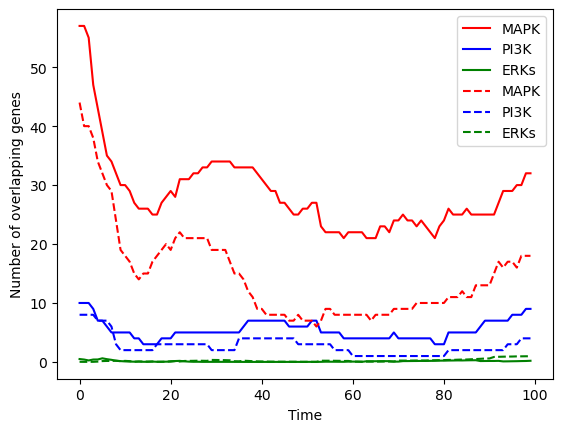

In [ ]:
plt.figure() 
plt.plot(mapk_cnts, 'r-', label='MAPK')
plt.plot(pi3k_cnts, 'b-', label='PI3K')
plt.plot(erks_pvals, 'g-', label='ERKs')
#plt.plot(apop_pvals, 'y-', label='Apoptosis')
#plt.plot(her2_pvals, 'k-', label='HER2')

plt.plot(mapk_cnts2, 'r--', label='MAPK')
plt.plot(pi3k_cnts2, 'b--', label='PI3K')
plt.plot(erks_pvals2, 'g--', label='ERKs')
#plt.plot(apop_pvals2, 'y--', label='Apoptosis')
#plt.plot(her2_pvals2, 'k--', label='HER2')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Number of overlapping genes')
plt.show()

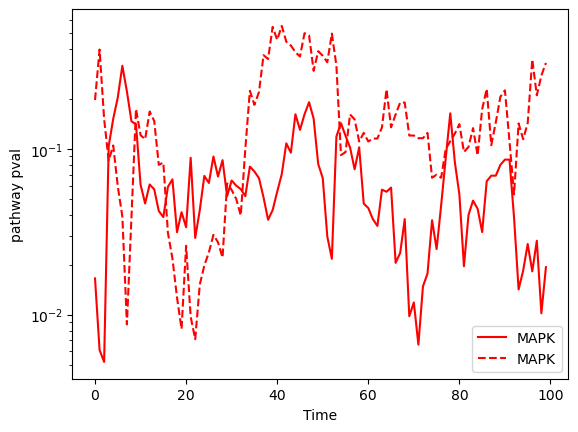

In [ ]:
plt.figure() 
plt.plot(mapk_pvals, 'r-', label='MAPK')
#plt.plot(pi3k_pvals, 'b-', label='PI3K')
#plt.plot(erks_pvals, 'g-', label='ERKs')
#plt.plot(apop_pvals, 'y-', label='Apoptosis')
#plt.plot(her2_pvals, 'k-', label='HER2')

plt.plot(mapk_pvals2, 'r--', label='MAPK')
#plt.plot(pi3k_pvals2, 'b--', label='PI3K')
#plt.plot(erks_pvals2, 'g--', label='ERKs')
#plt.plot(apop_pvals2, 'y--', label='Apoptosis')
#plt.plot(her2_pvals2, 'k--', label='HER2')

plt.legend()
plt.xlabel('Time')
plt.ylabel('pathway pval')
plt.yscale('log')
plt.show()

/tmp/ipykernel_29940/4199844883.py:5: RuntimeWarning: divide by zero encountered in divide
  her2_ratio = (np.array(her2_cnts) - np.array(her2_cnts2)) / np.array(her2_cnts2)


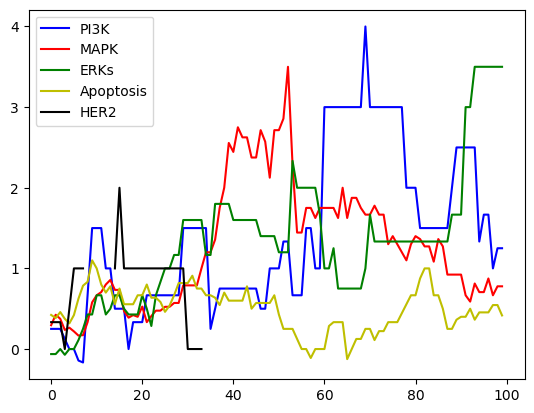

In [ ]:
pi3k_ratio = (np.array(pi3k_cnts) - np.array(pi3k_cnts2)) / np.array(pi3k_cnts2)
mapk_ratio = (np.array(mapk_cnts) - np.array(mapk_cnts2)) / np.array(mapk_cnts2)
erks_ratio = (np.array(erks_cnts) - np.array(erks_cnts2)) / np.array(erks_cnts2)
apop_ratio = (np.array(apop_cnts) - np.array(apop_cnts2)) / np.array(apop_cnts2)
her2_ratio = (np.array(her2_cnts) - np.array(her2_cnts2)) / np.array(her2_cnts2)

plt.figure() 
plt.plot(pi3k_ratio, 'b-', label='PI3K')
plt.plot(mapk_ratio, 'r-', label='MAPK')
plt.plot(erks_ratio, 'g-', label='ERKs')
plt.plot(apop_ratio, 'y-', label='Apoptosis')
plt.plot(her2_ratio, 'k-', label='HER2')
plt.legend()
plt.show() 

In [ ]:
mapk_genes = set(p2).intersection(set(nodes))
print(len(mapk_genes), '/', len(p2))

NameError: name 'nodes' is not defined

In [ ]:
nodes

array(['BRD-K54997624', 'C0HM02', 'MIMAT0000070', ..., 'Q9Y6P5', 'Q9Y6Q9',
       'Q9Y6R4'], shape=(1327,), dtype='<U13')

(array([6203., 3342., 1481.,  994.,  779.,  796.,  778.,  903., 1228.,
        8733.]),
 array([9.16215577e-05, 1.00081503e-01, 2.00071394e-01, 3.00061256e-01,
        4.00051147e-01, 5.00041068e-01, 6.00030899e-01, 7.00020790e-01,
        8.00010681e-01, 9.00000572e-01, 9.99990463e-01]),
 <BarContainer object of 10 artists>)

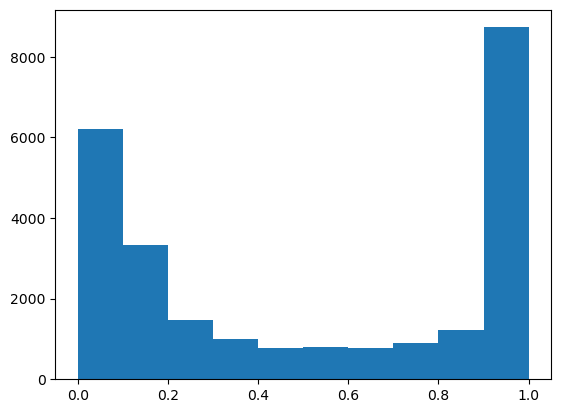

In [ ]:
from matplotlib import pyplot as plt 

plt.hist(res.weight.values)

In [ ]:


res = annotate_edges(model, wt_cell1) 
drug_edges = get_drug_edges(data, drug=drug) 
G = make_subgraph(data, res, drug_edges) 

genes = [G.nodes[n]['node_name'] for n in G.nodes()]
genes = [x for x in genes if x is not None ]

gsea = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                gene_sets=['GO_Biological_Process_2021'],
                organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                outdir=None, # don't write to disk
                background=background, # background gene list
                ).res2d 

return gsea 

In [ ]:
# Corrected hypergeometric test
def corrected_test_hgeom(genelist, pathway, data): 
    # Get the universe of genes that can be selected (only function nodes with UniProt IDs)
    universe_genes = set()
    for node_name in data.node_names_dict['function']:
        if '__' in node_name:
            universe_genes.add(node_name.split('__')[1])
    
    # Filter pathway and genelist to only include genes in the network universe
    pathway_filtered = list(set(pathway).intersection(universe_genes))
    genelist_filtered = list(set(genelist).intersection(universe_genes))
    
    N = len(universe_genes)  # Total genes that could be selected
    K = len(pathway_filtered)  # Pathway genes in the universe
    n = len(genelist_filtered)  # Genelist genes in the universe  
    k = len(set(genelist_filtered).intersection(pathway_filtered))  # Overlap
    
    if K == 0 or n == 0:
        return 1.0  # No enrichment possible
    
    # Survival function (P[X >= k])
    pval = hypergeom.sf(k-1, N, K, n)
    return pval 

print("=== Corrected test ===")
corrected_pval = corrected_test_hgeom(nodes, p1, data)
original_pval = test_hgeom(nodes, p1, data)

print(f"Original p-value: {original_pval}")
print(f"Corrected p-value: {corrected_pval}")
print(f"Graph size: {len(G.nodes())} nodes, {len(G.edges())} edges")


In [ ]:
# Check the weight threshold issue
print("=== Weight distribution analysis ===")
print(f"Total edges in results: {len(res)}")
print(f"Edges with weight > 0.5: {len(res[res.weight > 0.5])}")
print(f"Edges with weight > 0.1: {len(res[res.weight > 0.1])}")
print(f"Edges with weight > 0.01: {len(res[res.weight > 0.01])}")

print(f"\nWeight statistics:")
print(f"Min weight: {res.weight.min():.6f}")
print(f"Max weight: {res.weight.max():.6f}")
print(f"Mean weight: {res.weight.mean():.6f}")
print(f"Median weight: {res.weight.median():.6f}")

# Try with different thresholds
thresholds = [0.5, 0.1, 0.05, 0.01]
for threshold in thresholds:
    print(f"\n--- Threshold {threshold} ---")
    G_test = nx.DiGraph()
    for i, row in res[res.weight > threshold].iterrows(): 
        G_test.add_edge(row.src, row.dst)
    
    # Add drug edges
    for i in range(drug_edges.shape[1]): 
        src, dst = drug_edges[:, i] 
        src_name = data.node_names_dict['input'][src]
        dst_name = data.node_names_dict['function'][dst]
        if dst_name in G_test: 
            G_test.add_edge(src_name, dst_name)
    
    nodes_test = np.unique([x.split('__')[1] for x in list(G_test.nodes()) if '__' in x])
    print(f"Nodes in graph: {len(G_test.nodes())}")
    print(f"Edges in graph: {len(G_test.edges())}")
    print(f"Unique UniProt IDs: {len(nodes_test)}")
    
    if len(nodes_test) > 0:
        pval = corrected_test_hgeom(nodes_test, p1, data)
        print(f"PI3K p-value: {pval:.6f}")
